# Semantic shift -> stochastic conformance

For every comparison pair `L1` vs `L2`:

1. **Embeddings** - one CWINDOW compass per pair, then a frozen-output model per log, so both
   logs' activity embeddings live in the same space.
2. **Semantic shift** - per-activity cross-log cosine similarity over the shared activities;
   the bottom decile is *shifted*, the top decile *stable*.
3. **Stochastic conformance** - both logs are projected onto each selected activity's local
   context (`t-c .. t+c`) and the two stochastic languages are compared with EMSC
   (Earth Mover's Stochastic Conformance, via Ebi: conformance = 1 - distance).

The expectation under test: stable activities should reach a **higher** EMSC than shifted ones.
One summary table at the end; the only other output is the training / EMSC progress.

## Configuration

Settings shared by the whole experiment (`LEFT_WINDOW_SIZE`, `EMBEDDING_DIM`,
`BALANCE_COMPASS`, `QUANTILE_SHIFTED`, `QUANTILE_STABLE`) are globals. A log named `X` is
read from `LOGS_DIR/X.xes`.

`PAIRS` then lists the comparisons: one entry per `L1` vs `L2`, each spelling out its own
training schedule (learning rates and epochs for the compass and the per-log retraining),
so a single pair can be tuned without touching the others. Nothing is inherited - omitting
or misspelling one raises.

In [1]:
# --- Imports -----------------------------------------------------------------
import gc
import os

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
from IPython.display import display

import pm4py
import emsc_runner
import log_comparison_simple

# --- Reproducibility ---------------------------------------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- Fixed settings ----------------------------------------------------------
MODEL_TYPE = "CWINDOW"   # the only architecture used here
DEVICE = "cpu"           # small full-batch runs; MPS is slower for these
EMSC_TIMEOUT = 300       # seconds allowed per EMSC; the activity is skipped if it
                         # overruns (None = wait forever)
LOGS_DIR = "logs"        # a log named X is read from LOGS_DIR/X.xes

RECOMPUTE_EMBEDDINGS = True
EMBEDDINGS_PATH = "embeddings.pt"
TRAIN_EMBEDDINGS = RECOMPUTE_EMBEDDINGS or not os.path.exists(EMBEDDINGS_PATH)

# --- Global experiment settings (identical for every pair) -------------------
LEFT_WINDOW_SIZE = 4     # context window c; projection spans t-c .. t+c
EMBEDDING_DIM = 32       # activity embedding dimension
BALANCE_COMPASS = True   # scale the smaller log's rows by the case-count imbalance so
                         # both logs weigh equally in the compass loss; nothing is
                         # resampled, and the per-log retraining stays unweighted
QUANTILE_SHIFTED = 0.10  # cosine <= this quantile -> shifted
QUANTILE_STABLE = 0.90   # cosine >= this quantile -> stable

# --- One comparison entry ----------------------------------------------------
# Every pair states its own full set of per-pair hyperparameters, so any pair can be
# tuned without touching the others. Nothing is inherited: a missing or misspelled
# hyperparameter raises instead of silently falling back to a default.
#
#   compass_learning_rate / compass_epochs    compass stage (the shared space)
#   log_learning_rate / log_epochs            per-log frozen-output retraining
HYPERPARAM_KEYS = (
    "compass_learning_rate",
    "compass_epochs",
    "log_learning_rate",
    "log_epochs",
)


def pair(l1, l2, **hyperparams):
    """One comparison: the two log names plus every hyperparameter it runs with."""
    missing = [k for k in HYPERPARAM_KEYS if k not in hyperparams]
    unknown = [k for k in hyperparams if k not in HYPERPARAM_KEYS]
    if missing or unknown:
        raise ValueError(
            f"{l1} vs {l2}: "
            + (f"missing hyperparameters {missing}. " if missing else "")
            + (f"unknown hyperparameters {unknown}." if unknown else "")
        )
    return {"l1": l1, "l2": l2, **hyperparams}


def pair_id(p):
    return f"{p['l1']} vs {p['l2']}"


# --- The experiment ----------------------------------------------------------
PAIRS = [
    # --- BPIC11 age ---
    pair("BPIC11_age_low", "BPIC11_age_high",
         compass_learning_rate=1e-2, compass_epochs=500,
         log_learning_rate=1e-2, log_epochs=1500),

    # --- BPIC15 municipalities ---
    pair("BPIC15_M1", "BPIC15_M2",
         compass_learning_rate=1e-2, compass_epochs=500,
         log_learning_rate=1e-2, log_epochs=500),
    pair("BPIC15_M1", "BPIC15_M3",
         compass_learning_rate=1e-2, compass_epochs=500,
         log_learning_rate=1e-2, log_epochs=500),
    pair("BPIC15_M1", "BPIC15_M4",
         compass_learning_rate=1e-2, compass_epochs=500,
         log_learning_rate=1e-2, log_epochs=500),
    pair("BPIC15_M1", "BPIC15_M5",
         compass_learning_rate=1e-2, compass_epochs=500,
         log_learning_rate=1e-2, log_epochs=500),
    pair("BPIC15_M2", "BPIC15_M3",
         compass_learning_rate=1e-2, compass_epochs=500,
         log_learning_rate=1e-2, log_epochs=500),
    pair("BPIC15_M2", "BPIC15_M4",
         compass_learning_rate=1e-2, compass_epochs=500,
         log_learning_rate=1e-2, log_epochs=500),
    pair("BPIC15_M2", "BPIC15_M5",
         compass_learning_rate=1e-2, compass_epochs=500,
         log_learning_rate=1e-2, log_epochs=500),
    pair("BPIC15_M3", "BPIC15_M4",
         compass_learning_rate=1e-2, compass_epochs=500,
         log_learning_rate=1e-2, log_epochs=500),
    pair("BPIC15_M3", "BPIC15_M5",
         compass_learning_rate=1e-2, compass_epochs=500,
         log_learning_rate=1e-2, log_epochs=500),
    pair("BPIC15_M4", "BPIC15_M5",
         compass_learning_rate=1e-2, compass_epochs=500,
         log_learning_rate=1e-2, log_epochs=500),

    # --- BPIC18 departments ---
    pair("BPIC18_D4e", "BPIC18_D6b",
         compass_learning_rate=1e-2, compass_epochs=500,
         log_learning_rate=1e-2, log_epochs=1000),
    pair("BPIC18_D4e", "BPIC18_Dd4",
         compass_learning_rate=1e-2, compass_epochs=500,
         log_learning_rate=1e-2, log_epochs=1000),
    pair("BPIC18_D4e", "BPIC18_De7",
         compass_learning_rate=1e-2, compass_epochs=500,
         log_learning_rate=1e-2, log_epochs=1000),
    pair("BPIC18_D6b", "BPIC18_Dd4",
         compass_learning_rate=1e-2, compass_epochs=500,
         log_learning_rate=1e-2, log_epochs=1000),
    pair("BPIC18_D6b", "BPIC18_De7",
         compass_learning_rate=1e-2, compass_epochs=500,
         log_learning_rate=1e-2, log_epochs=1000),
    pair("BPIC18_Dd4", "BPIC18_De7",
         compass_learning_rate=1e-2, compass_epochs=500,
         log_learning_rate=1e-2, log_epochs=1000),

    # --- RTFM vehicle classes ---
    # pair("RTFM_A", "RTFM_C",
    #      compass_learning_rate=1e-2, compass_epochs=1000,
    #      log_learning_rate=1e-2, log_epochs=1000),
    # pair("RTFM_A", "RTFM_M",
    #      compass_learning_rate=1e-2, compass_epochs=1000,
    #      log_learning_rate=1e-2, log_epochs=1000),
    # pair("RTFM_A", "RTFM_R",
    #      compass_learning_rate=1e-2, compass_epochs=1000,
    #      log_learning_rate=1e-2, log_epochs=1000),
    # pair("RTFM_M", "RTFM_C",
    #      compass_learning_rate=1e-2, compass_epochs=1000,
    #      log_learning_rate=1e-2, log_epochs=1000),
    # pair("RTFM_M", "RTFM_R",
    #      compass_learning_rate=1e-2, compass_epochs=1000,
    #      log_learning_rate=1e-2, log_epochs=1000),
    # pair("RTFM_C", "RTFM_R",
    #      compass_learning_rate=1e-2, compass_epochs=1000,
    #      log_learning_rate=1e-2, log_epochs=1000),
]

print(f"{len(PAIRS)} pairs: {', '.join(pair_id(p) for p in PAIRS)}")

17 pairs: BPIC11_age_low vs BPIC11_age_high, BPIC15_M1 vs BPIC15_M2, BPIC15_M1 vs BPIC15_M3, BPIC15_M1 vs BPIC15_M4, BPIC15_M1 vs BPIC15_M5, BPIC15_M2 vs BPIC15_M3, BPIC15_M2 vs BPIC15_M4, BPIC15_M2 vs BPIC15_M5, BPIC15_M3 vs BPIC15_M4, BPIC15_M3 vs BPIC15_M5, BPIC15_M4 vs BPIC15_M5, BPIC18_D4e vs BPIC18_D6b, BPIC18_D4e vs BPIC18_Dd4, BPIC18_D4e vs BPIC18_De7, BPIC18_D6b vs BPIC18_Dd4, BPIC18_D6b vs BPIC18_De7, BPIC18_Dd4 vs BPIC18_De7


## Load the logs

In [2]:
logs, activity_sets = {}, {}

for name in sorted({n for p in PAIRS for n in (p["l1"], p["l2"])}):
    df = pm4py.read_xes(f"{LOGS_DIR}/{name}.xes")
    # BPIC15 carries the readable label in activityNameEN; every other log labels its
    # events with concept:name directly
    if "activityNameEN" in df.columns:
        df["concept:name"] = df["activityNameEN"]
    logs[name] = df[["case:concept:name", "concept:name", "time:timestamp"]]
    activity_sets[name] = set(logs[name]["concept:name"].unique())

traces = {
    name: log_comparison_simple.convert_to_simpleEventLog(df) for name, df in logs.items()
}

/Users/felixgross/Documents/Python Projects/Comparing Event Logs/.venv/lib/python3.14/site-packages/pm4py/utils.py:1005: UserWarning: In the current version, the import/export operation uses `r4pm` by default for importing/exporting files faster.
  warnings.warn(


## Pairwise embeddings

One compass per pair, then a frozen-output model per log. A log therefore gets a *different*
embedding in each pair it appears in, so similarity is always measured inside a 2-log space.

With `balance_compass=True` the two logs contribute **equal weight** to the compass loss: the
trainer already weights every (context, target) pair by its cumulative case count and normalises
by the total weight, so the smaller log's cases are simply scaled by the size imbalance. No case
is dropped, duplicated or resampled - the balancing is deterministic, costs no extra training
samples, and every activity stays in the compass vocabulary. The subsequent per-log retraining
(frozen output layer) uses each log's **full, unweighted** trace multiset, so only the shared
reference frame is balanced.

Pairwise embeddings:   0%|          | 0/17 [00:00<?, ?it/s]

--- CWINDOW COMPASS on combined logs, case weights scaled by {'BPIC11_age_low': 1.0, 'BPIC11_age_high': 1.12} ---
Using device: cpu
Training CWINDOW — 500 epochs with learning rate 1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

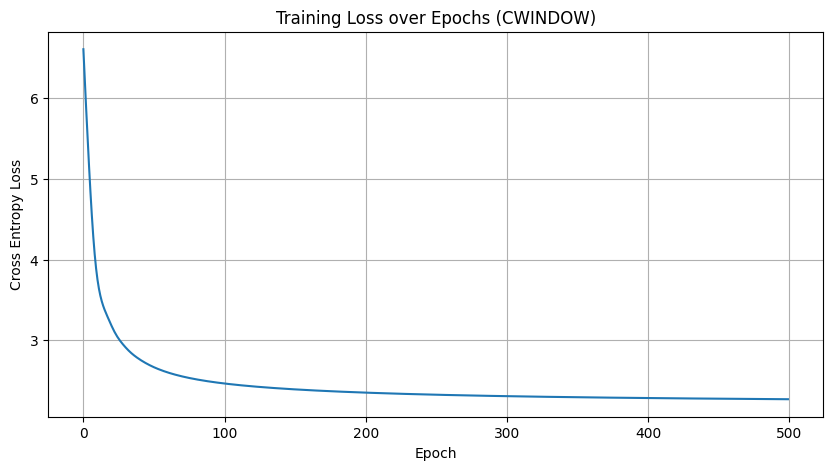

--- CWINDOW BPIC11_age_low ---
Using device: cpu
Retraining CWINDOW 1500 epochs with frozen output, lr=1.0e-02


  0%|          | 0/1500 [00:00<?, ?it/s]

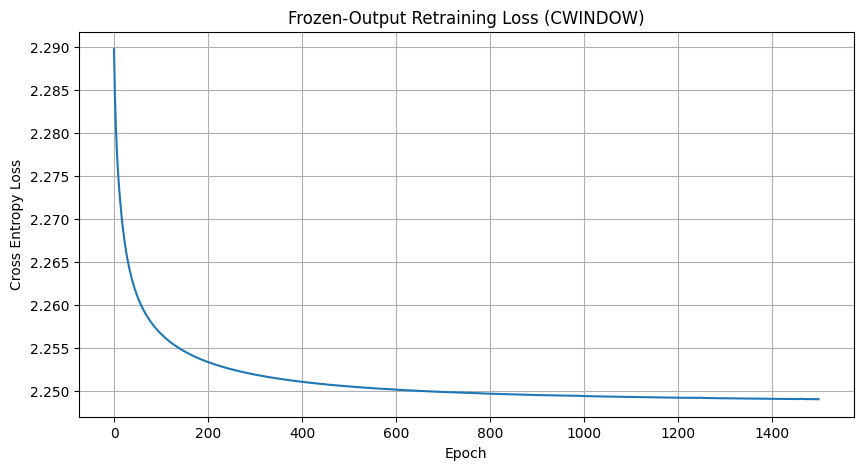

--- CWINDOW BPIC11_age_high ---
Using device: cpu
Retraining CWINDOW 1500 epochs with frozen output, lr=1.0e-02


  0%|          | 0/1500 [00:00<?, ?it/s]

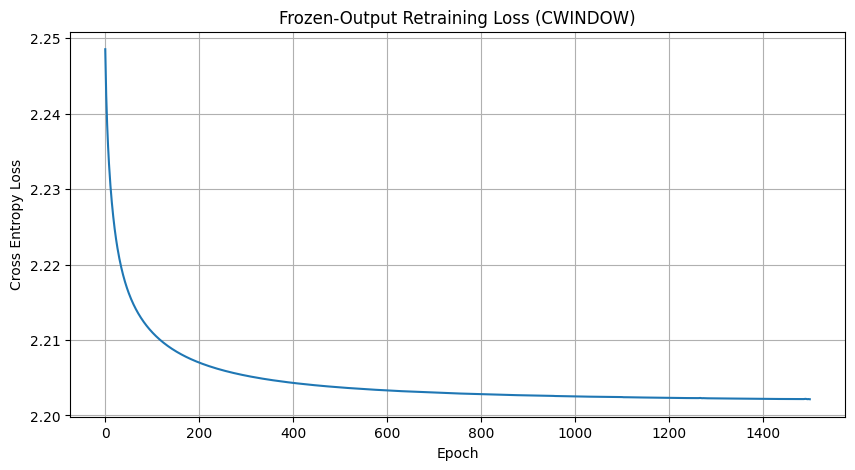

--- CWINDOW COMPASS on combined logs, case weights scaled by {'BPIC15_M1': 1.0, 'BPIC15_M2': 1.44} ---
Using device: cpu
Training CWINDOW — 500 epochs with learning rate 1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

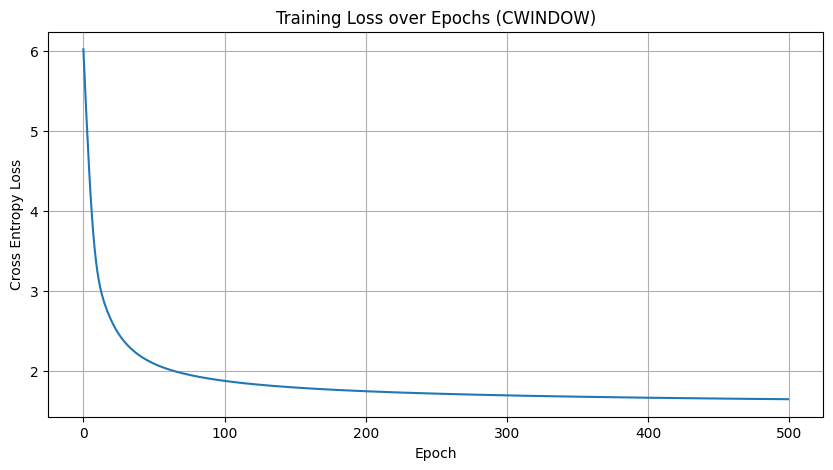

--- CWINDOW BPIC15_M1 ---
Using device: cpu
Retraining CWINDOW 500 epochs with frozen output, lr=1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

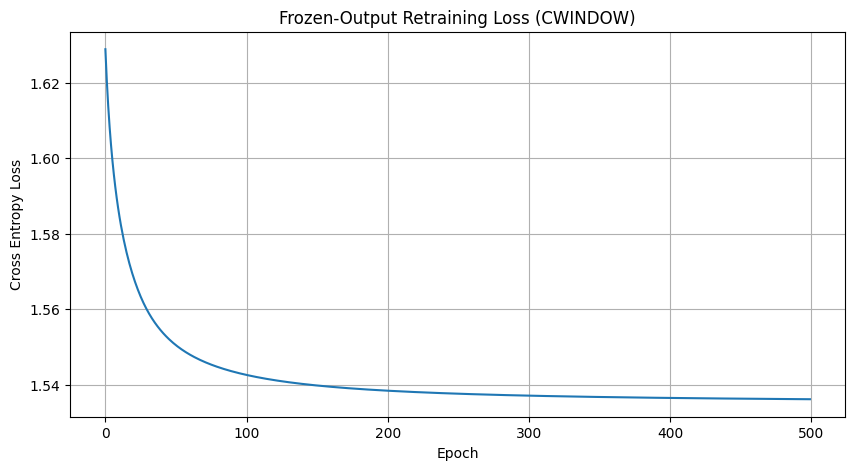

--- CWINDOW BPIC15_M2 ---
Using device: cpu
Retraining CWINDOW 500 epochs with frozen output, lr=1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

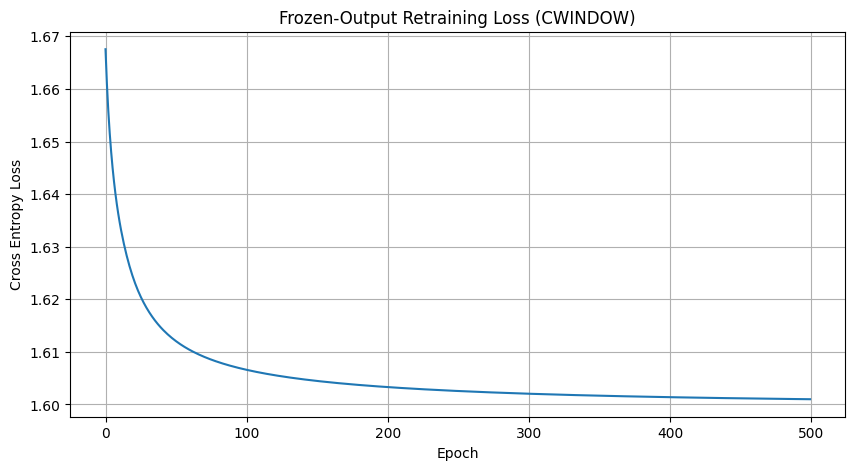

--- CWINDOW COMPASS on combined logs, case weights scaled by {'BPIC15_M1': 1.18, 'BPIC15_M3': 1.0} ---
Using device: cpu
Training CWINDOW — 500 epochs with learning rate 1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

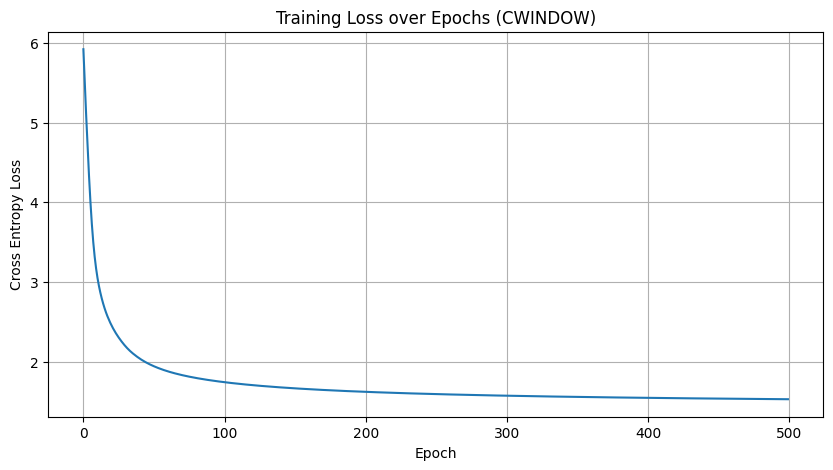

--- CWINDOW BPIC15_M1 ---
Using device: cpu
Retraining CWINDOW 500 epochs with frozen output, lr=1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

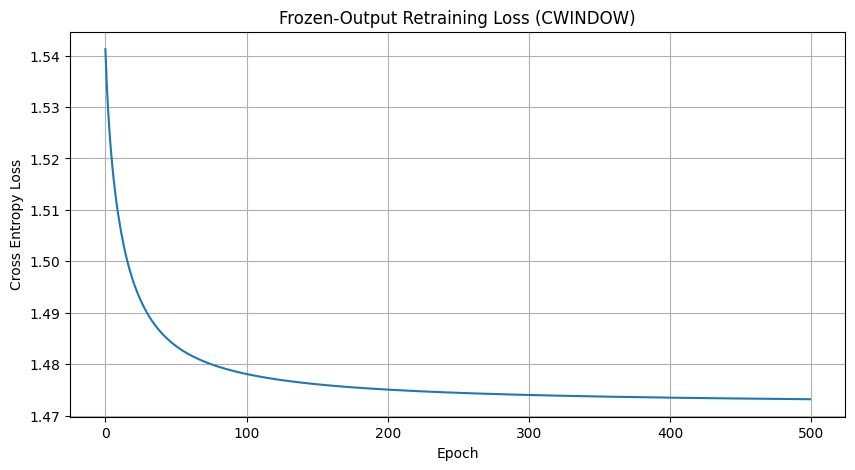

--- CWINDOW BPIC15_M3 ---
Using device: cpu
Retraining CWINDOW 500 epochs with frozen output, lr=1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

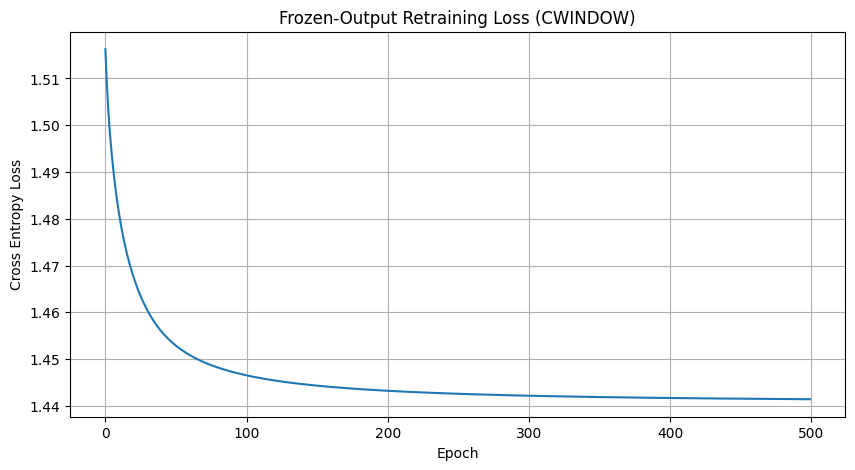

--- CWINDOW COMPASS on combined logs, case weights scaled by {'BPIC15_M1': 1.0, 'BPIC15_M4': 1.14} ---
Using device: cpu
Training CWINDOW — 500 epochs with learning rate 1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

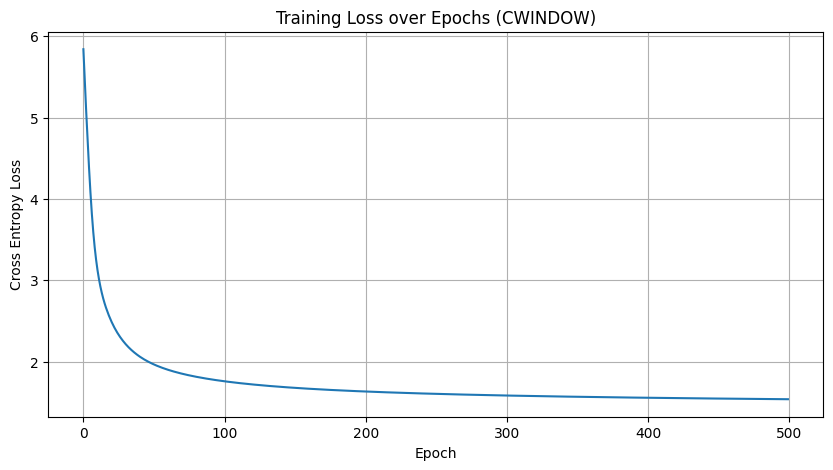

--- CWINDOW BPIC15_M1 ---
Using device: cpu
Retraining CWINDOW 500 epochs with frozen output, lr=1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

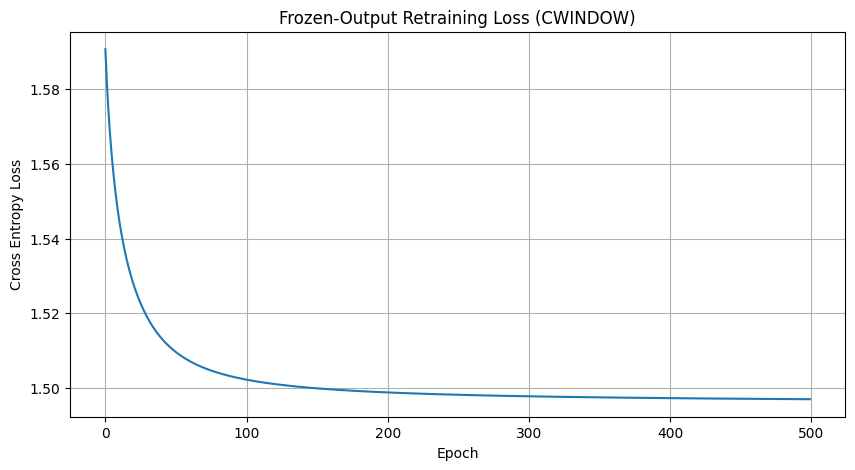

--- CWINDOW BPIC15_M4 ---
Using device: cpu
Retraining CWINDOW 500 epochs with frozen output, lr=1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

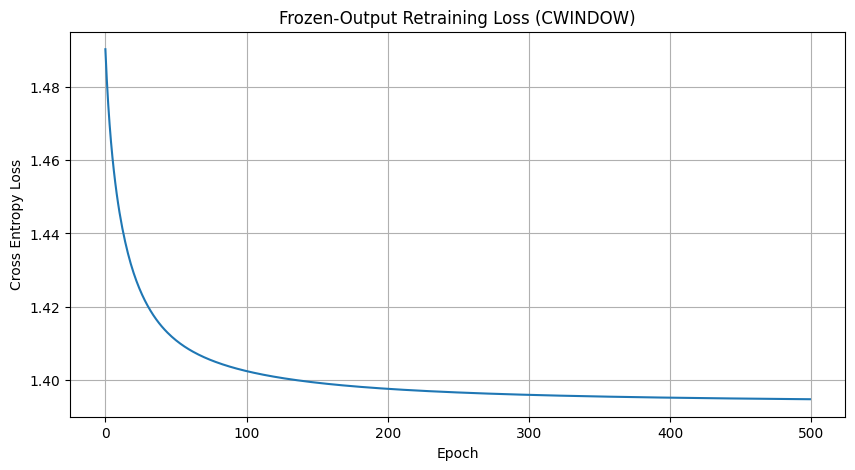

--- CWINDOW COMPASS on combined logs, case weights scaled by {'BPIC15_M1': 1.0, 'BPIC15_M5': 1.04} ---
Using device: cpu
Training CWINDOW — 500 epochs with learning rate 1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

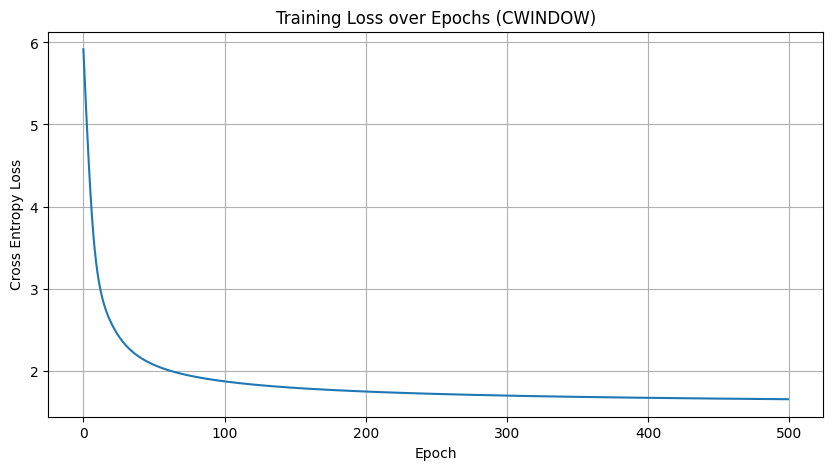

--- CWINDOW BPIC15_M1 ---
Using device: cpu
Retraining CWINDOW 500 epochs with frozen output, lr=1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

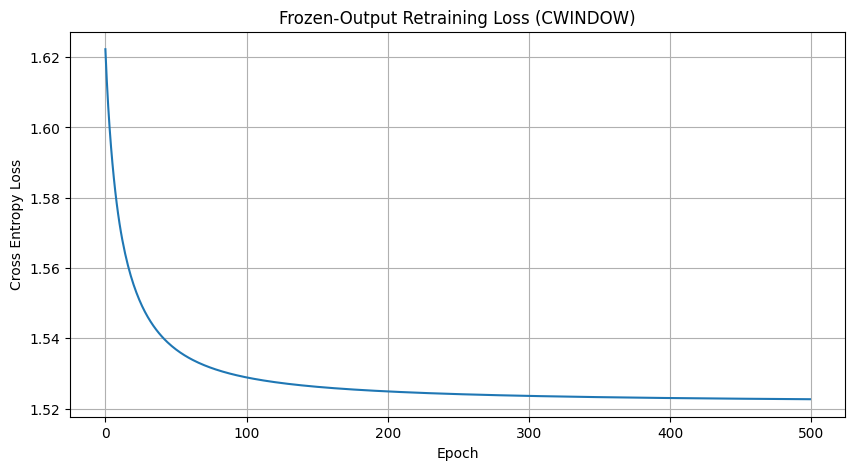

--- CWINDOW BPIC15_M5 ---
Using device: cpu
Retraining CWINDOW 500 epochs with frozen output, lr=1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

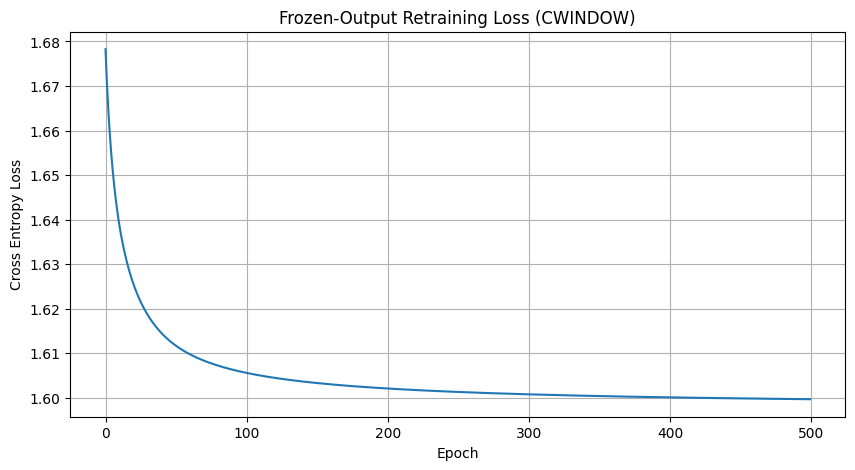

--- CWINDOW COMPASS on combined logs, case weights scaled by {'BPIC15_M2': 1.69, 'BPIC15_M3': 1.0} ---
Using device: cpu
Training CWINDOW — 500 epochs with learning rate 1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

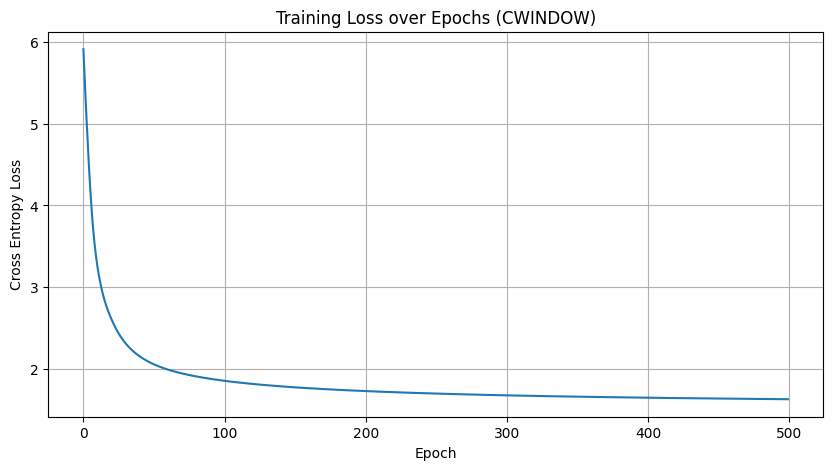

--- CWINDOW BPIC15_M2 ---
Using device: cpu
Retraining CWINDOW 500 epochs with frozen output, lr=1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

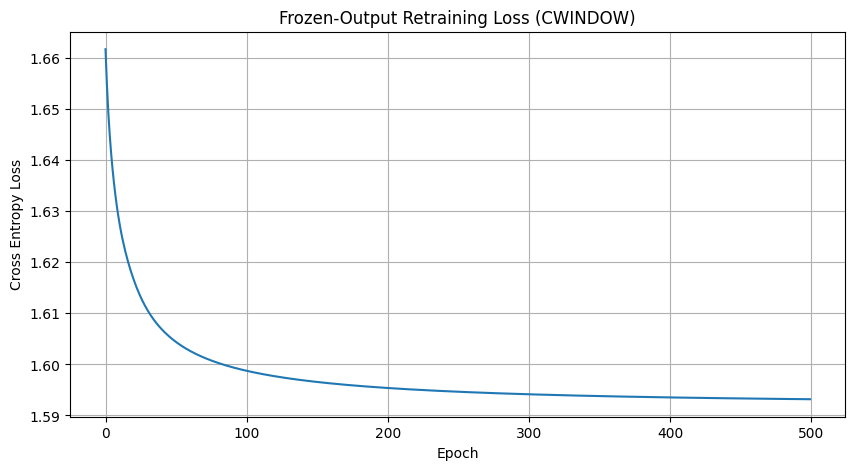

--- CWINDOW BPIC15_M3 ---
Using device: cpu
Retraining CWINDOW 500 epochs with frozen output, lr=1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

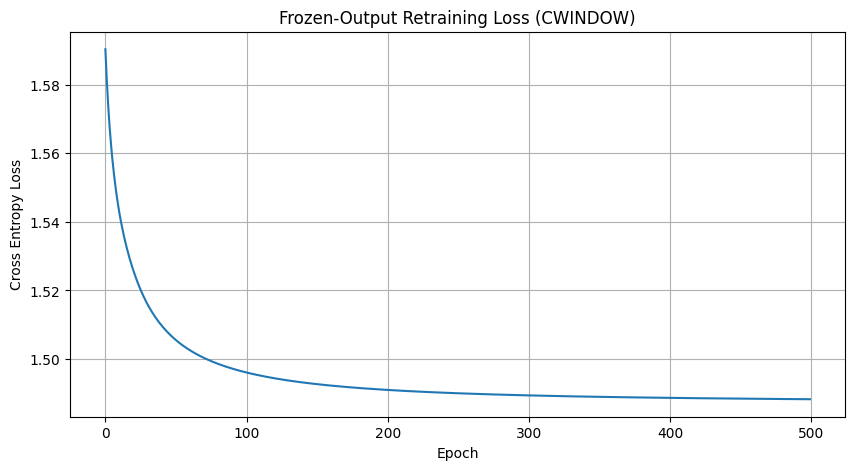

--- CWINDOW COMPASS on combined logs, case weights scaled by {'BPIC15_M2': 1.27, 'BPIC15_M4': 1.0} ---
Using device: cpu
Training CWINDOW — 500 epochs with learning rate 1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

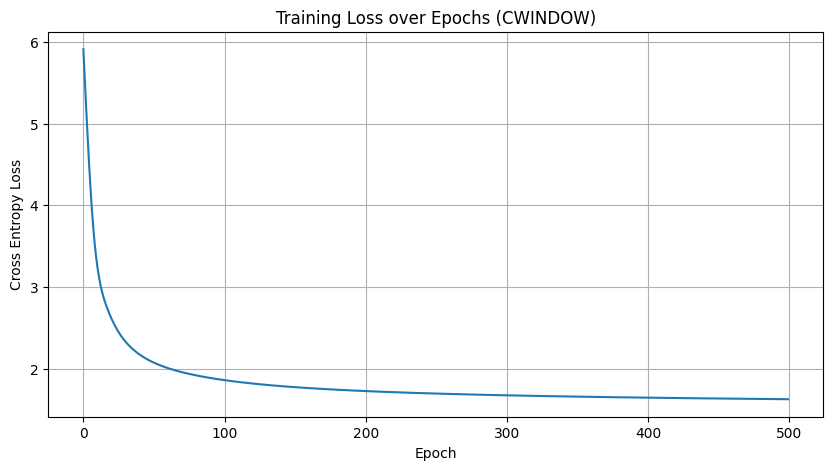

--- CWINDOW BPIC15_M2 ---
Using device: cpu
Retraining CWINDOW 500 epochs with frozen output, lr=1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

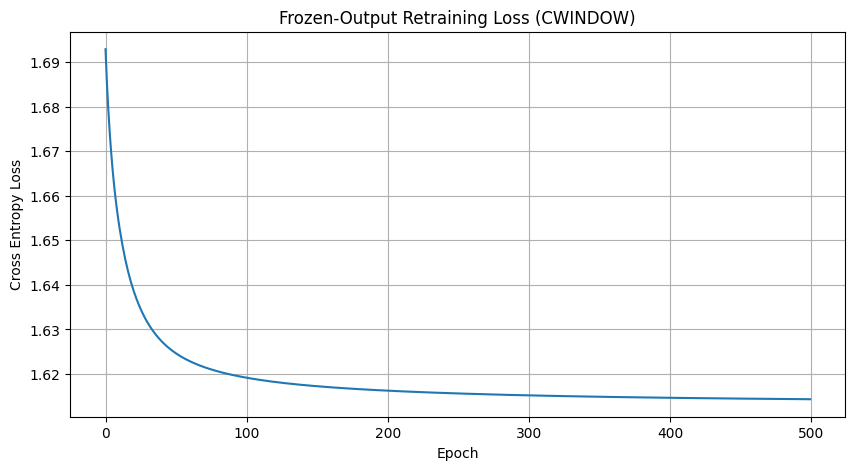

--- CWINDOW BPIC15_M4 ---
Using device: cpu
Retraining CWINDOW 500 epochs with frozen output, lr=1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

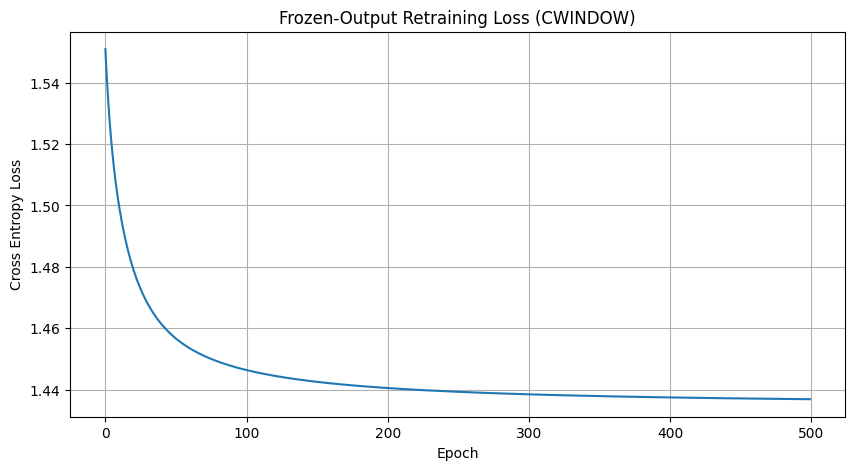

--- CWINDOW COMPASS on combined logs, case weights scaled by {'BPIC15_M2': 1.39, 'BPIC15_M5': 1.0} ---
Using device: cpu
Training CWINDOW — 500 epochs with learning rate 1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

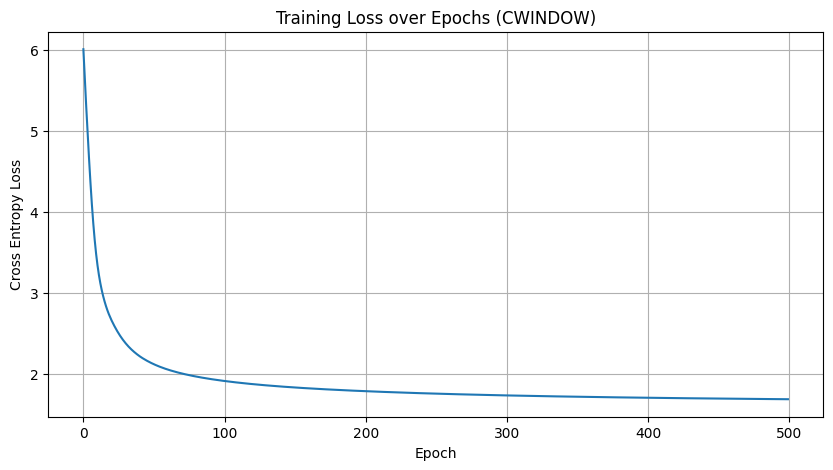

--- CWINDOW BPIC15_M2 ---
Using device: cpu
Retraining CWINDOW 500 epochs with frozen output, lr=1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

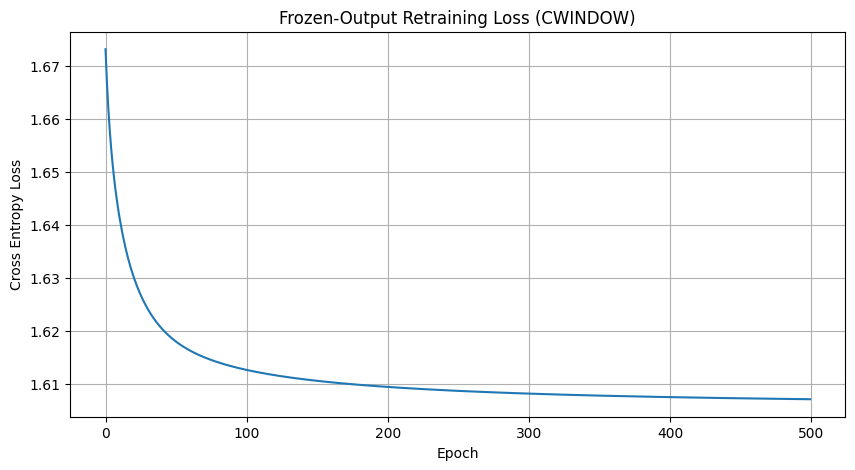

--- CWINDOW BPIC15_M5 ---
Using device: cpu
Retraining CWINDOW 500 epochs with frozen output, lr=1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

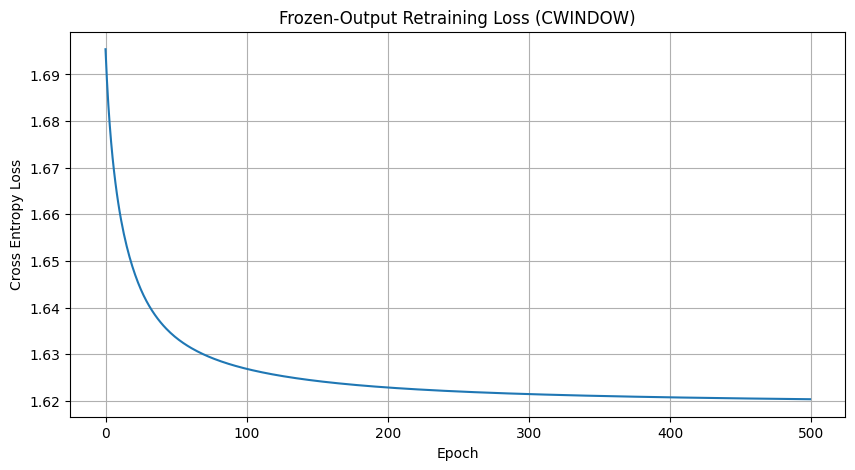

--- CWINDOW COMPASS on combined logs, case weights scaled by {'BPIC15_M3': 1.0, 'BPIC15_M4': 1.34} ---
Using device: cpu
Training CWINDOW — 500 epochs with learning rate 1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

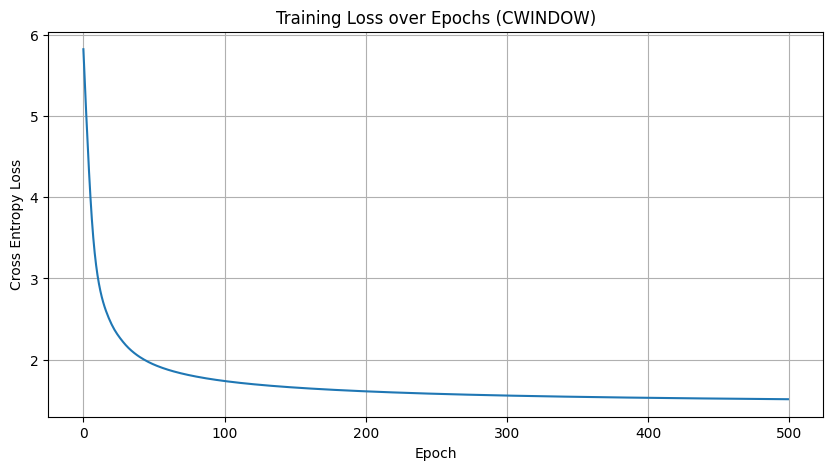

--- CWINDOW BPIC15_M3 ---
Using device: cpu
Retraining CWINDOW 500 epochs with frozen output, lr=1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

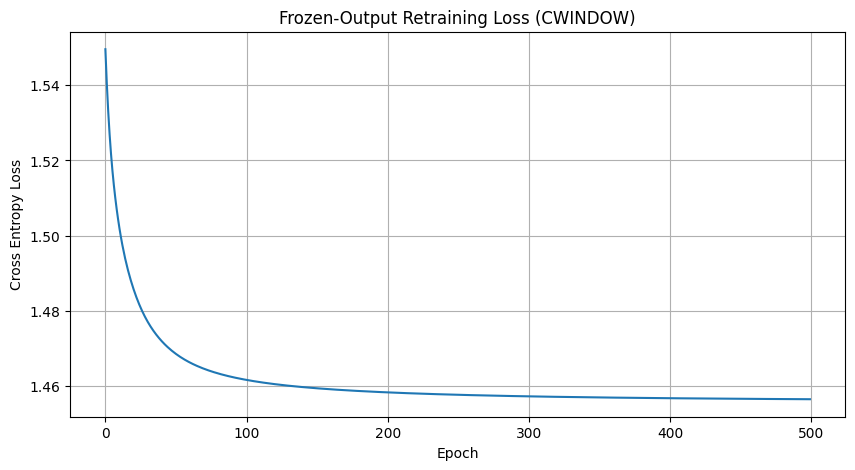

--- CWINDOW BPIC15_M4 ---
Using device: cpu
Retraining CWINDOW 500 epochs with frozen output, lr=1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

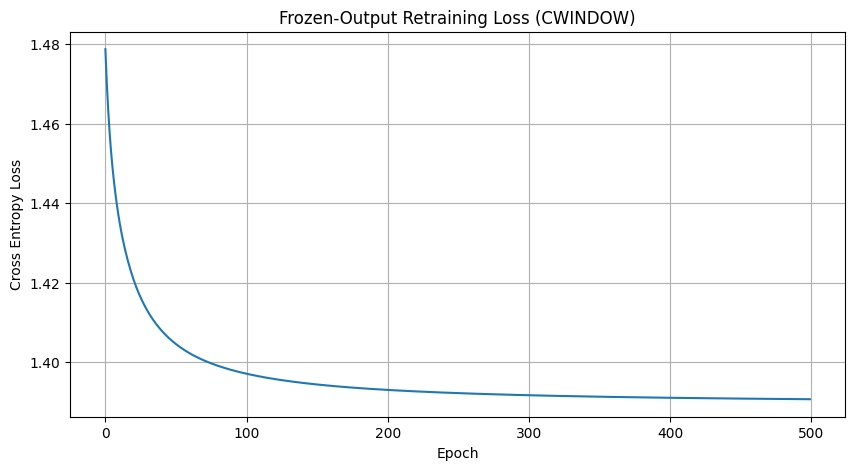

--- CWINDOW COMPASS on combined logs, case weights scaled by {'BPIC15_M3': 1.0, 'BPIC15_M5': 1.22} ---
Using device: cpu
Training CWINDOW — 500 epochs with learning rate 1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

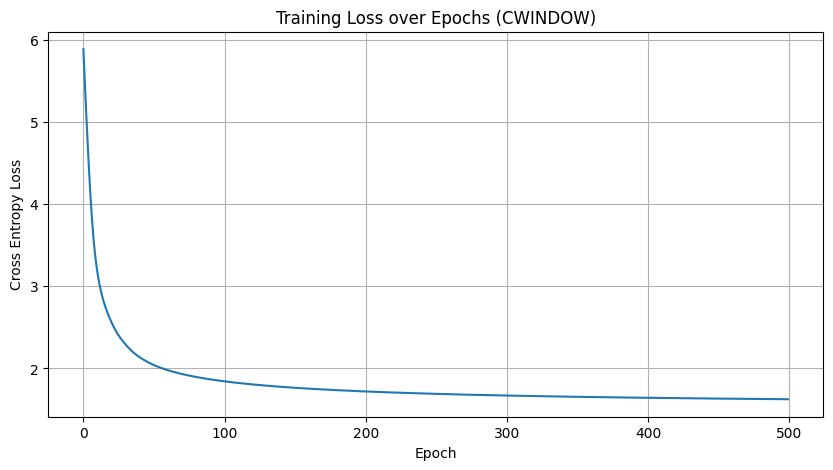

--- CWINDOW BPIC15_M3 ---
Using device: cpu
Retraining CWINDOW 500 epochs with frozen output, lr=1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

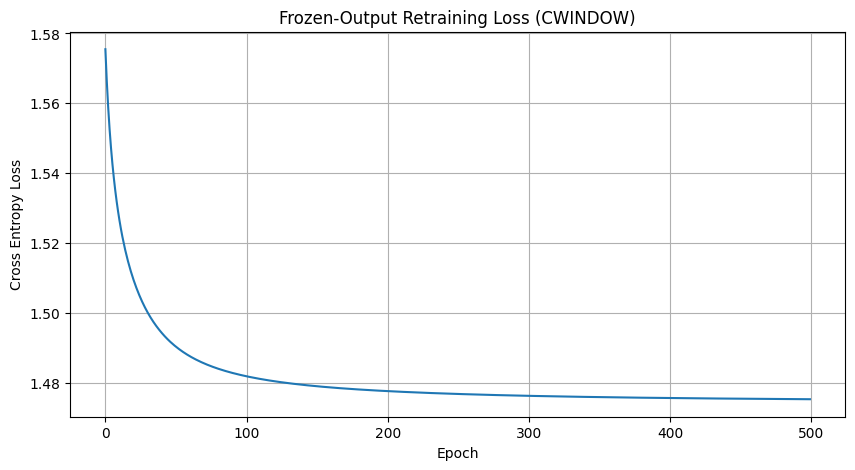

--- CWINDOW BPIC15_M5 ---
Using device: cpu
Retraining CWINDOW 500 epochs with frozen output, lr=1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

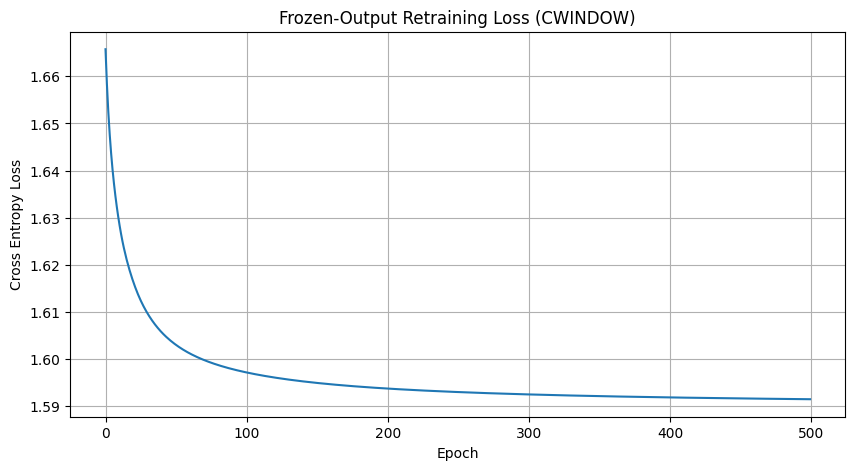

--- CWINDOW COMPASS on combined logs, case weights scaled by {'BPIC15_M4': 1.1, 'BPIC15_M5': 1.0} ---
Using device: cpu
Training CWINDOW — 500 epochs with learning rate 1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

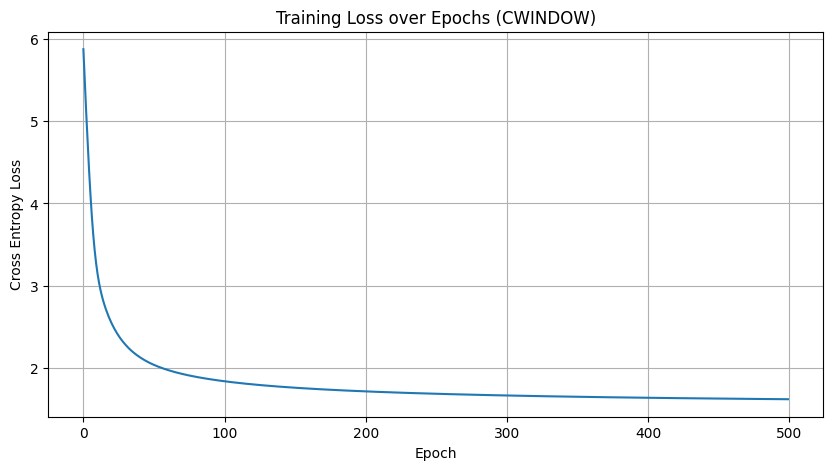

--- CWINDOW BPIC15_M4 ---
Using device: cpu
Retraining CWINDOW 500 epochs with frozen output, lr=1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

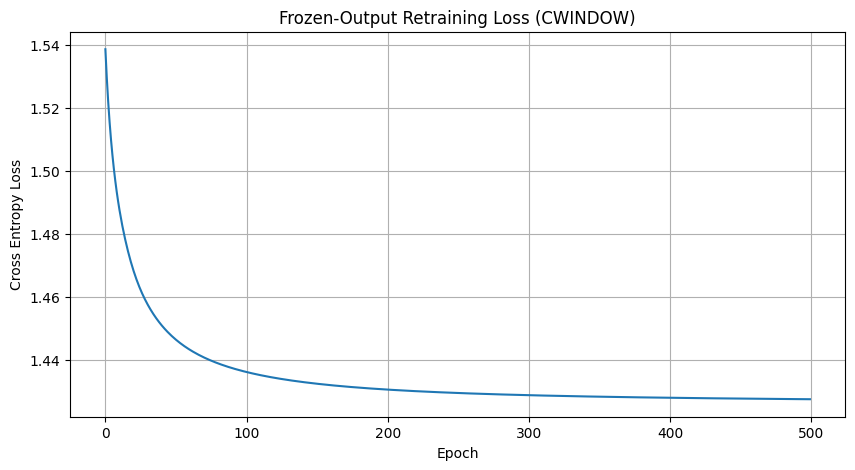

--- CWINDOW BPIC15_M5 ---
Using device: cpu
Retraining CWINDOW 500 epochs with frozen output, lr=1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

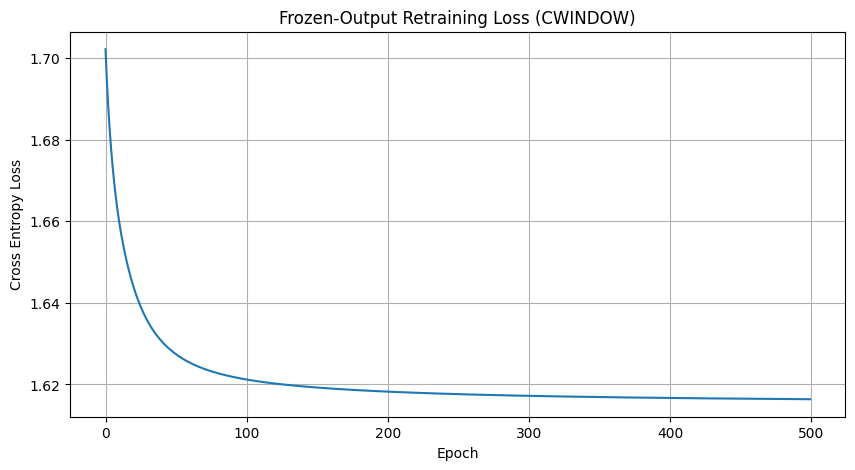

--- CWINDOW COMPASS on combined logs, case weights scaled by {'BPIC18_D4e': 1.0, 'BPIC18_D6b': 1.21} ---
Using device: cpu
Training CWINDOW — 500 epochs with learning rate 1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

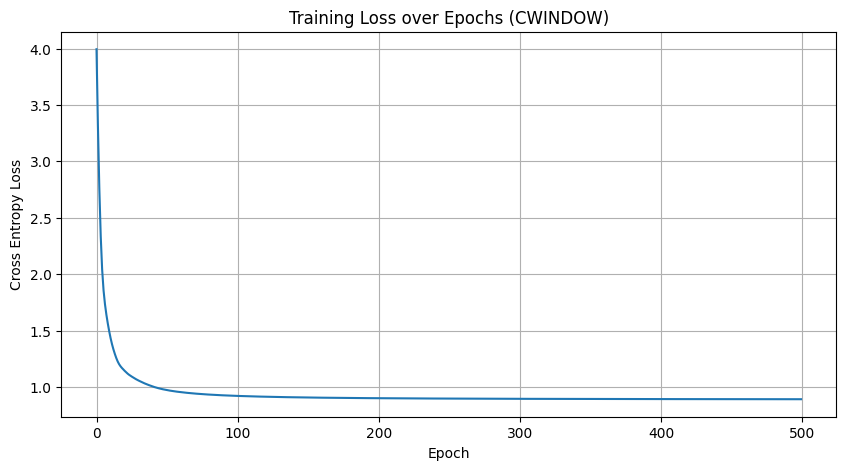

--- CWINDOW BPIC18_D4e ---
Using device: cpu
Retraining CWINDOW 1000 epochs with frozen output, lr=1.0e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

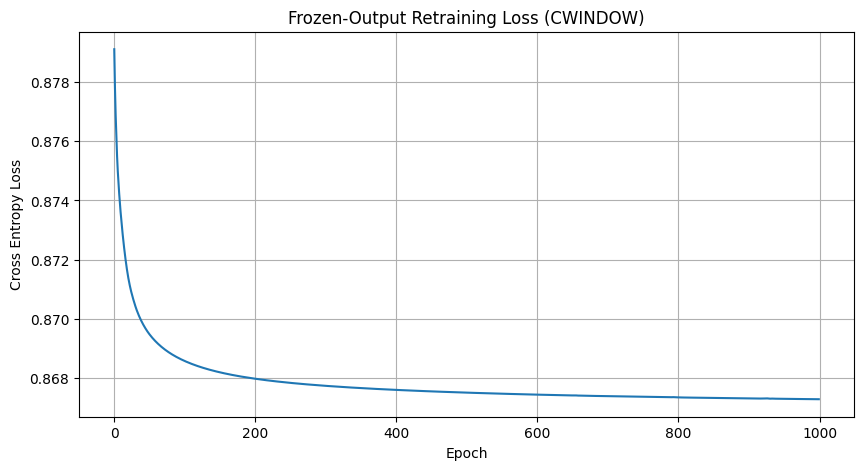

--- CWINDOW BPIC18_D6b ---
Using device: cpu
Retraining CWINDOW 1000 epochs with frozen output, lr=1.0e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

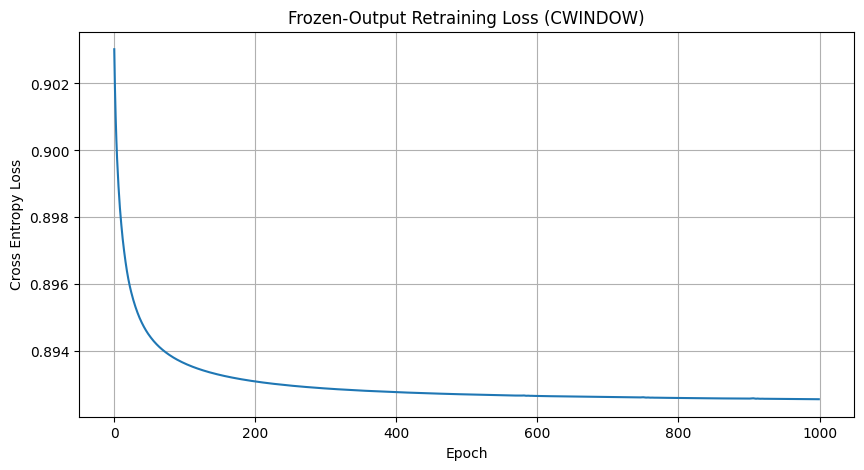

--- CWINDOW COMPASS on combined logs, case weights scaled by {'BPIC18_D4e': 1.0, 'BPIC18_Dd4': 2.37} ---
Using device: cpu
Training CWINDOW — 500 epochs with learning rate 1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

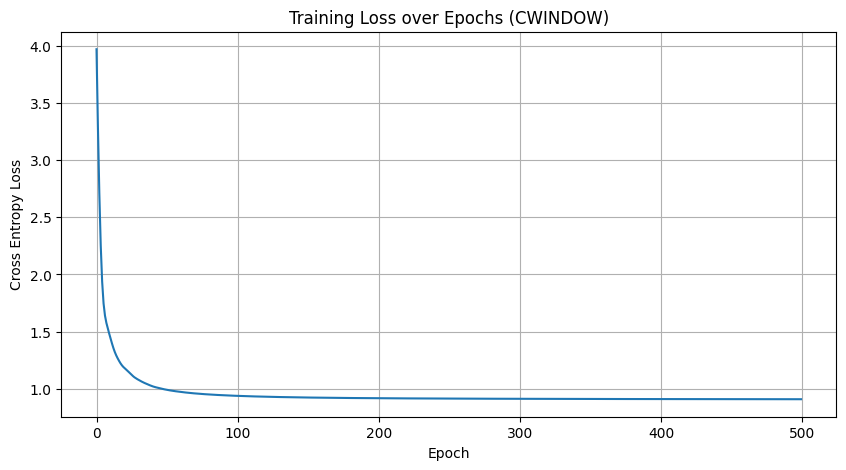

--- CWINDOW BPIC18_D4e ---
Using device: cpu
Retraining CWINDOW 1000 epochs with frozen output, lr=1.0e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

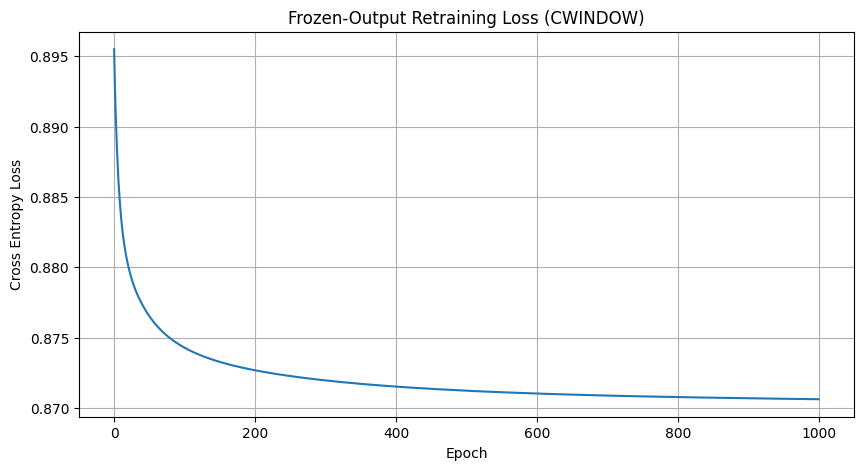

--- CWINDOW BPIC18_Dd4 ---
Using device: cpu
Retraining CWINDOW 1000 epochs with frozen output, lr=1.0e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

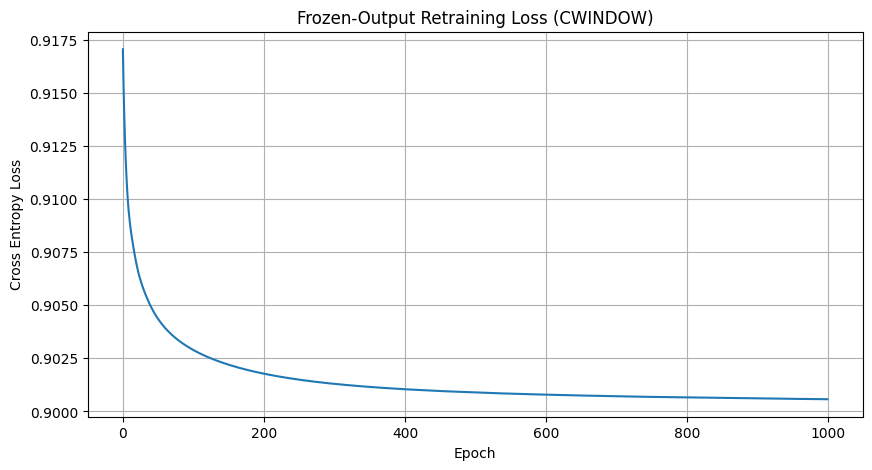

--- CWINDOW COMPASS on combined logs, case weights scaled by {'BPIC18_D4e': 1.0, 'BPIC18_De7': 1.04} ---
Using device: cpu
Training CWINDOW — 500 epochs with learning rate 1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

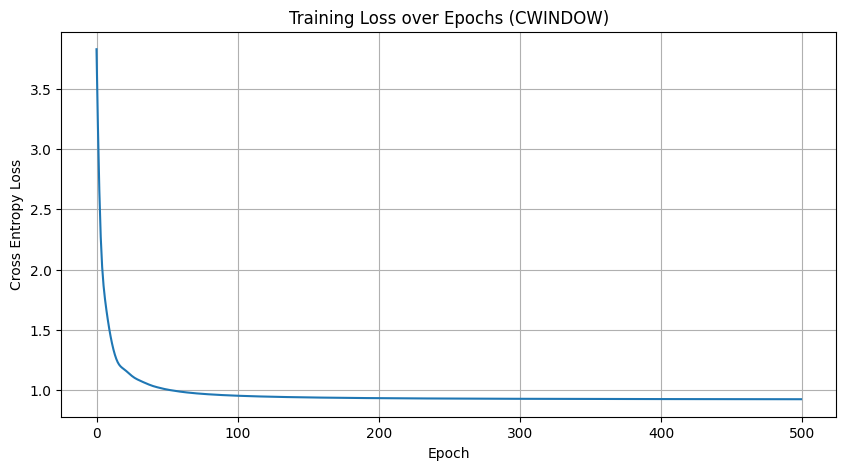

--- CWINDOW BPIC18_D4e ---
Using device: cpu
Retraining CWINDOW 1000 epochs with frozen output, lr=1.0e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

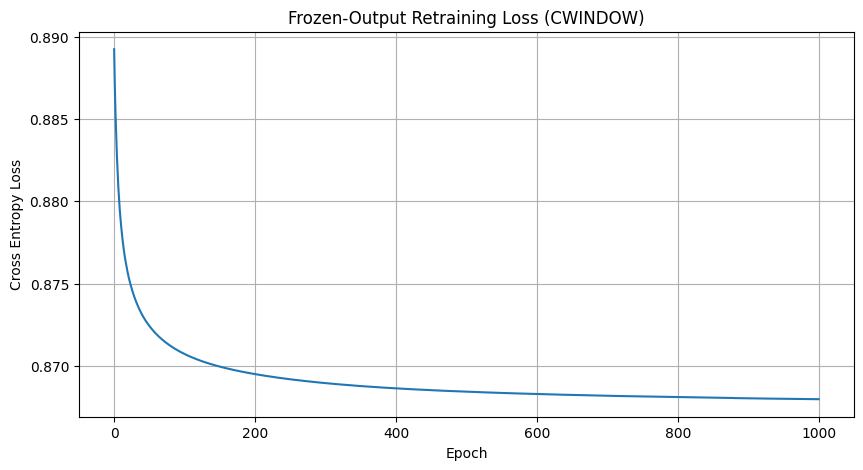

--- CWINDOW BPIC18_De7 ---
Using device: cpu
Retraining CWINDOW 1000 epochs with frozen output, lr=1.0e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

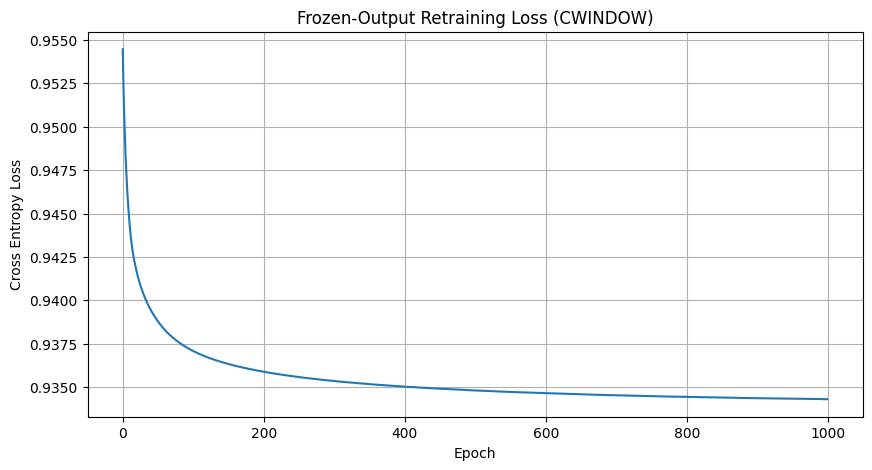

--- CWINDOW COMPASS on combined logs, case weights scaled by {'BPIC18_D6b': 1.0, 'BPIC18_Dd4': 1.96} ---
Using device: cpu
Training CWINDOW — 500 epochs with learning rate 1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

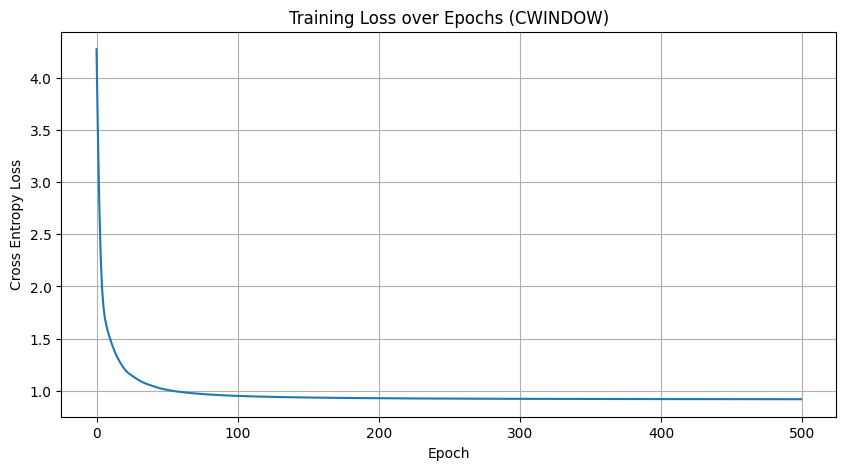

--- CWINDOW BPIC18_D6b ---
Using device: cpu
Retraining CWINDOW 1000 epochs with frozen output, lr=1.0e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

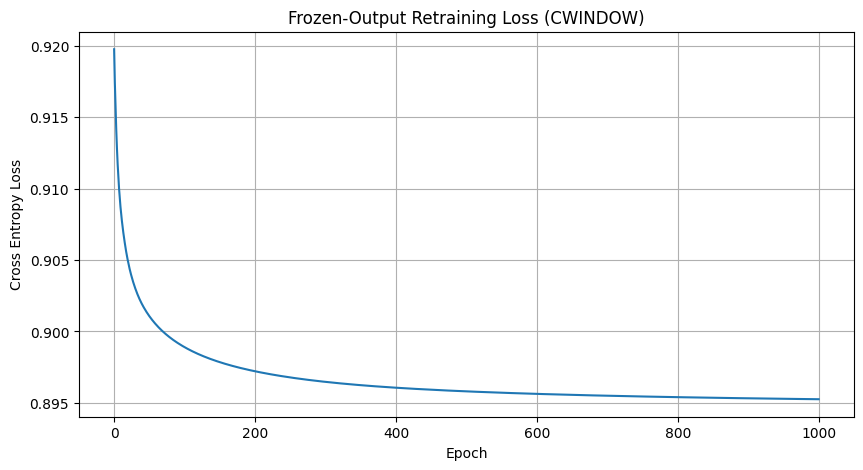

--- CWINDOW BPIC18_Dd4 ---
Using device: cpu
Retraining CWINDOW 1000 epochs with frozen output, lr=1.0e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

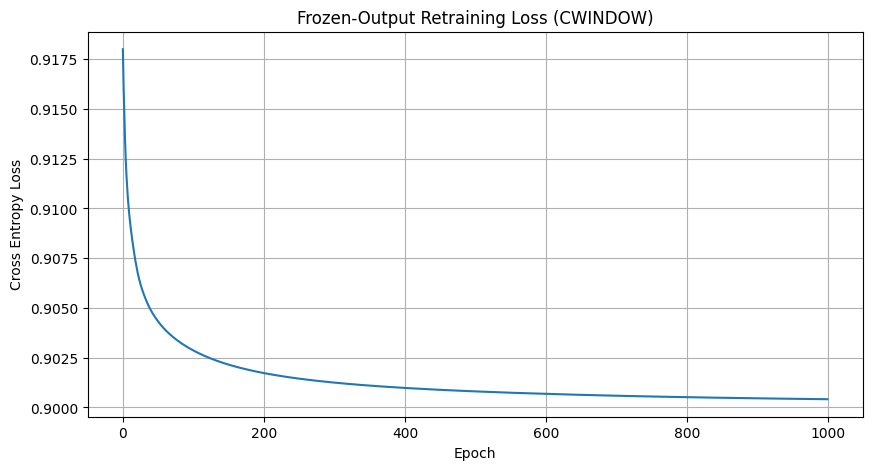

--- CWINDOW COMPASS on combined logs, case weights scaled by {'BPIC18_D6b': 1.17, 'BPIC18_De7': 1.0} ---
Using device: cpu
Training CWINDOW — 500 epochs with learning rate 1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

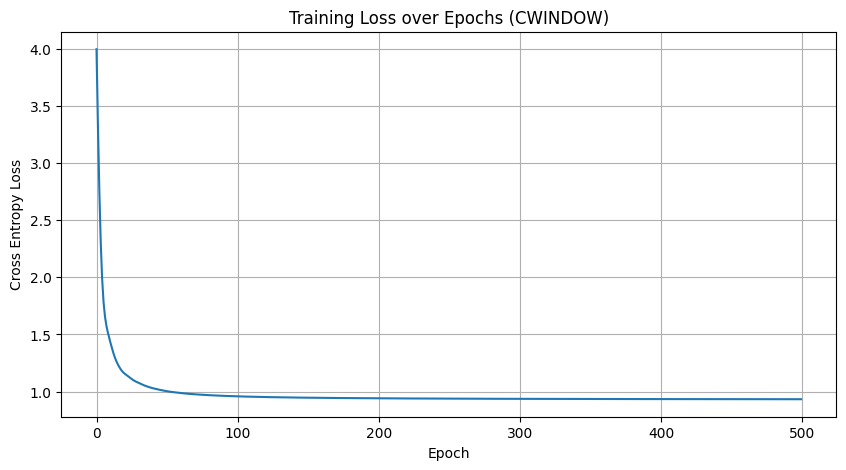

--- CWINDOW BPIC18_D6b ---
Using device: cpu
Retraining CWINDOW 1000 epochs with frozen output, lr=1.0e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

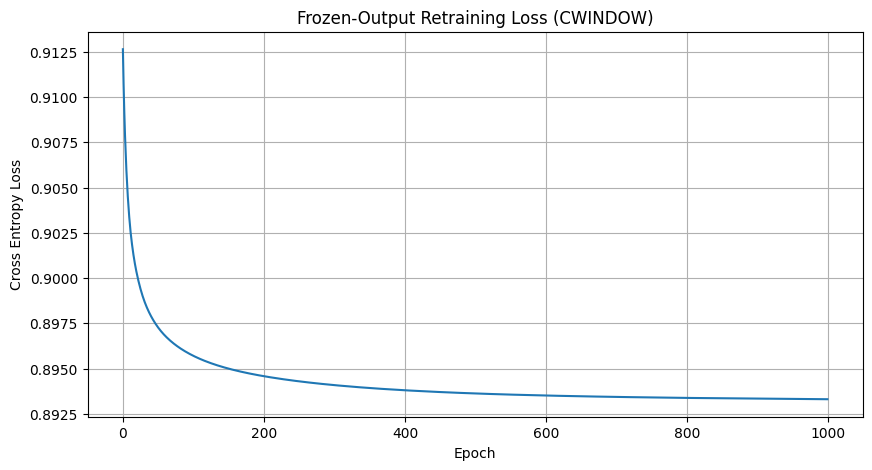

--- CWINDOW BPIC18_De7 ---
Using device: cpu
Retraining CWINDOW 1000 epochs with frozen output, lr=1.0e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

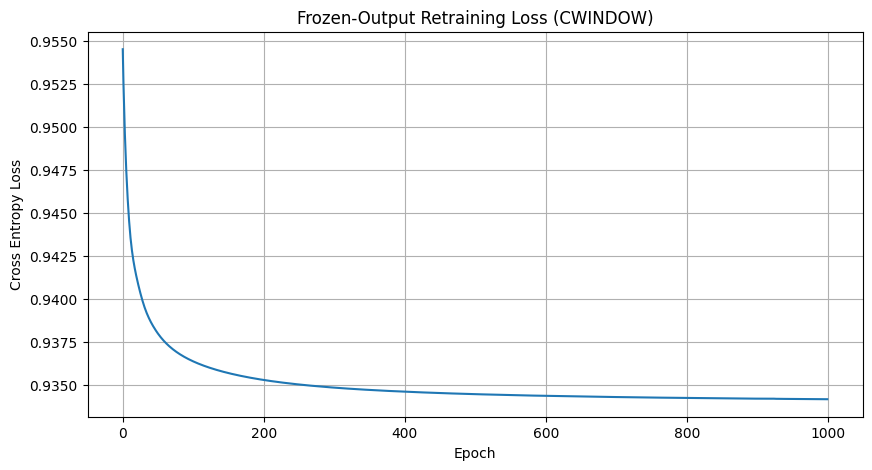

--- CWINDOW COMPASS on combined logs, case weights scaled by {'BPIC18_Dd4': 2.29, 'BPIC18_De7': 1.0} ---
Using device: cpu
Training CWINDOW — 500 epochs with learning rate 1.0e-02


  0%|          | 0/500 [00:00<?, ?it/s]

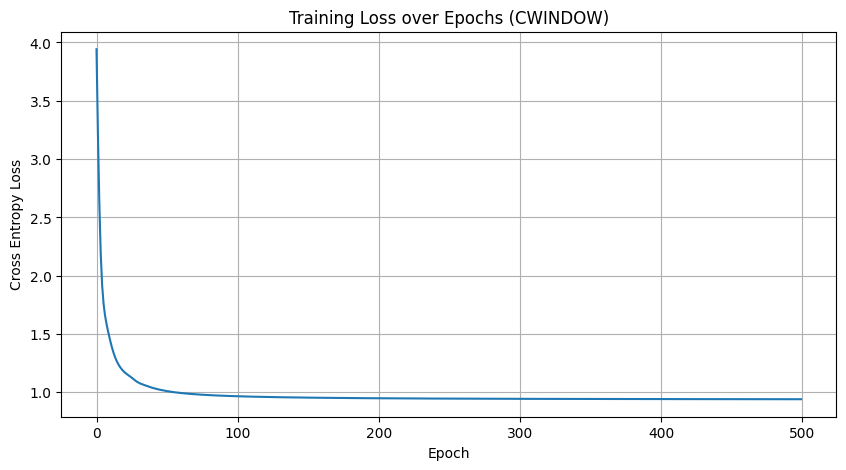

--- CWINDOW BPIC18_Dd4 ---
Using device: cpu
Retraining CWINDOW 1000 epochs with frozen output, lr=1.0e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

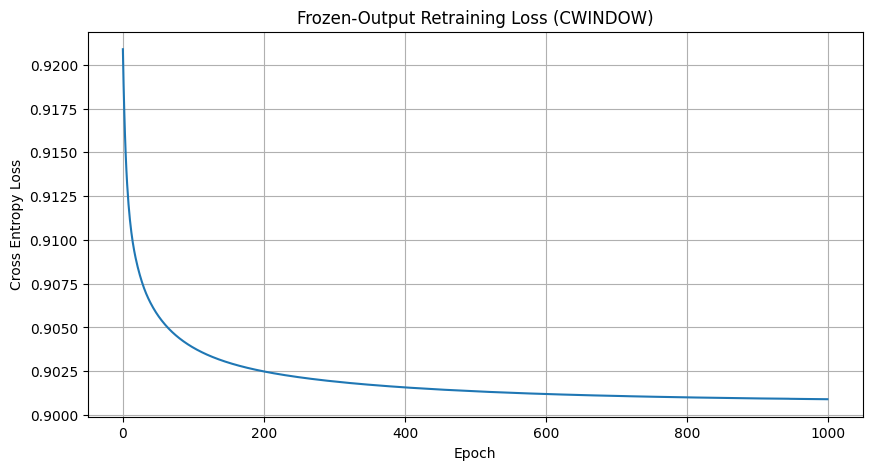

--- CWINDOW BPIC18_De7 ---
Using device: cpu
Retraining CWINDOW 1000 epochs with frozen output, lr=1.0e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

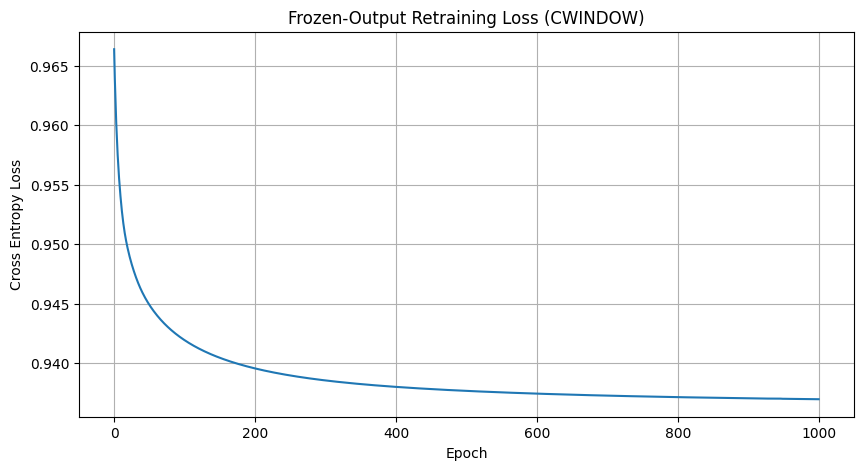

Trained and cached 17 pairs -> embeddings.pt


In [3]:
if TRAIN_EMBEDDINGS:
    models = {}
    for p in tqdm(PAIRS, desc="Pairwise embeddings"):
        l1, l2 = p["l1"], p["l2"]
        comparison = log_comparison_simple.compare_event_logs(
            MODEL_TYPE,
            {l1: traces[l1], l2: traces[l2]},
            left_window_size=LEFT_WINDOW_SIZE,
            embedding_dim=EMBEDDING_DIM,
            compass_learning_rate=p["compass_learning_rate"],
            compass_epochs=p["compass_epochs"],
            log_learning_rate=p["log_learning_rate"],
            log_epochs=p["log_epochs"],
            balance_compass=BALANCE_COMPASS,
            device=DEVICE,
            verbose=True,
        )
        models[pair_id(p)] = comparison.models

    log_comparison_simple.save_models(
        EMBEDDINGS_PATH,
        {
            f"{pid}::{name}": model_tuple
            for pid, per_log in models.items()
            for name, model_tuple in per_log.items()
        },
    )
    print(f"Trained and cached {len(models)} pairs -> {EMBEDDINGS_PATH}")
else:
    models = {}
    for key, model_tuple in log_comparison_simple.load_models(EMBEDDINGS_PATH).items():
        pid, name = key.rsplit("::", 1)
        models.setdefault(pid, {})[name] = model_tuple
    missing = [pair_id(p) for p in PAIRS if pair_id(p) not in models]
    if missing:
        raise RuntimeError(
            f"{EMBEDDINGS_PATH} has no models for {missing} - "
            "set RECOMPUTE_EMBEDDINGS = True and retrain"
        )
    print(f"Loaded cached embeddings for {len(models)} pairs")

## Cross-log cosine similarity and anchor selection

Per pair: cosine similarity of every shared activity across the two logs, then the bottom
decile (*shifted*) and the top decile (*stable*).

In [4]:
anchors = {}

for p in PAIRS:
    pid, l1, l2 = pair_id(p), p["l1"], p["l2"]
    model_1, word_to_ix = models[pid][l1]
    model_2, _ = models[pid][l2]

    shared = sorted(
        a for a in activity_sets[l1] & activity_sets[l2] if a in word_to_ix
    )
    ids = torch.tensor([word_to_ix[a] for a in shared])
    with torch.no_grad():
        e1 = F.normalize(model_1.embeddings.weight[ids].cpu().float(), p=2, dim=1)
        e2 = F.normalize(model_2.embeddings.weight[ids].cpu().float(), p=2, dim=1)
    cos = pd.Series((e1 * e2).sum(dim=1).numpy(), index=shared, name="cosine")

    q_shifted = float(np.quantile(cos.values, QUANTILE_SHIFTED))
    q_stable = float(np.quantile(cos.values, QUANTILE_STABLE))
    anchors[pid] = {
        "cos": cos,
        "q_shifted": q_shifted,
        "q_stable": q_stable,
        "shifted": list(cos.index[cos.values <= q_shifted]),
        "stable": list(cos.index[cos.values >= q_stable]),
    }

## EMSC between the projected sub-logs

One EMSC per selected activity: both logs are projected onto that activity's local context and
the two projections are compared directly (no train/eval direction).

In [5]:
# One comparison at a time, one activity at a time: project both logs onto the activity,
# compute the EMSC, keep the result, move on. Partial results are on disk after every pair.
#
# emsc_runner.emsc_with_timeout runs the Ebi call in a throwaway child process and kills it
# after EMSC_TIMEOUT seconds, so a stuck activity costs at most that and only that activity
# is lost. The child process is unavoidable: Ebi is a compiled extension, so a signal-based
# timeout would only fire once the call had already finished.
emsc_rows, failures = [], []

for p in tqdm(PAIRS, desc="Comparisons"):
    pid, l1, l2 = pair_id(p), p["l1"], p["l2"]
    entry = anchors[pid]
    selected = [(group, a) for group in ("stable", "shifted") for a in entry[group]]

    pair_failures = []
    for group, activity in tqdm(selected, desc=pid, leave=False):
        row = {"pair": pid, "group": group, "activity": activity,
               "cosine": float(entry["cos"][activity])}

        df_1 = log_comparison_simple.project_log_on_context(
            logs[l1], {activity}, LEFT_WINDOW_SIZE
        )
        df_2 = log_comparison_simple.project_log_on_context(
            logs[l2], {activity}, LEFT_WINDOW_SIZE
        )
        if df_1.empty or df_2.empty:
            pair_failures.append({**row, "error": "empty sub-log"})
            continue

        try:
            value = emsc_runner.emsc_with_timeout(df_1, df_2, timeout=EMSC_TIMEOUT)
            emsc_rows.append({**row, "value": value})
        except TimeoutError:
            pair_failures.append({**row, "error": f"timeout after {EMSC_TIMEOUT}s"})
        except Exception as exc:
            pair_failures.append({**row, "error": str(exc)})

    failures += pair_failures
    if pair_failures:
        n_timeout = sum("timeout" in f["error"] for f in pair_failures)
        print(f"{pid}: {len(pair_failures)} of {len(selected)} activities failed "
              f"({n_timeout} timed out)")

    # partial save, so an interrupted run keeps what is already done
    pd.DataFrame(emsc_rows).to_csv("stochastic_conformance_results.csv", index=False)
    gc.collect()

emsc = pd.DataFrame(emsc_rows)
emsc.to_csv("stochastic_conformance_results.csv", index=False)
print(f"{len(emsc)} EMSC values over {len(PAIRS)} comparisons"
      + (f", {len(failures)} failed" if failures else ""))

Comparisons:   0%|          | 0/17 [00:00<?, ?it/s]

BPIC11_age_low vs BPIC11_age_high:   0%|          | 0/74 [00:00<?, ?it/s]

BPIC11_age_low vs BPIC11_age_high: 4 of 74 activities failed (4 timed out)


BPIC15_M1 vs BPIC15_M2:   0%|          | 0/54 [00:00<?, ?it/s]

BPIC15_M1 vs BPIC15_M3:   0%|          | 0/50 [00:00<?, ?it/s]

...

BPIC18_D6b vs BPIC18_Dd4: 2 of 10 activities failed (1 timed out)


BPIC18_D6b vs BPIC18_De7:   0%|          | 0/10 [00:00<?, ?it/s]

BPIC18_D6b vs BPIC18_De7: 3 of 10 activities failed (2 timed out)


BPIC18_Dd4 vs BPIC18_De7:   0%|          | 0/10 [00:00<?, ?it/s]

BPIC18_Dd4 vs BPIC18_De7: 1 of 10 activities failed (0 timed out)
630 EMSC values over 17 comparisons, 18 failed


## Results

One row per comparison pair.

* **shared / total acts** - activity alphabet overlap of the two logs.
* **eligible acts** - shared activities that have an embedding in the pair's compass; the
  set the quantiles are taken over.
* **cos min / q10 / median / q90 / max** - cross-log cosine similarity over the eligible
  activities. `q10` is the *shifted* cut-off (cosine at or below it), `q90` the *stable* one;
  the two follow `QUANTILE_SHIFTED` / `QUANTILE_STABLE`.
* **EMSC shifted / stable / delta** - mean EMSC per group and their difference; positive delta
  is the expected direction.
* **win rate** - share of the (stable, shifted) activity comparisons *within this pair* where the
  stable activity reaches the higher EMSC. 50% = no relationship, > 50% supports the hypothesis.

In [6]:
col_q_shifted = f"cos q{round(QUANTILE_SHIFTED * 100)} (shifted <=)"
col_q_stable = f"cos q{round(QUANTILE_STABLE * 100)} (stable >=)"

rows = []
for p in PAIRS:
    pid, l1, l2 = pair_id(p), p["l1"], p["l2"]
    entry = anchors[pid]
    cos = entry["cos"].values

    sub = emsc[emsc["pair"] == pid]
    stable = sub.loc[sub["group"] == "stable", "value"].dropna().values
    shifted = sub.loc[sub["group"] == "shifted", "value"].dropna().values

    total = stable.size * shifted.size
    wins = int((stable[:, None] > shifted[None, :]).sum()) if total else 0

    n_shared = len(activity_sets[l1] & activity_sets[l2])
    n_total = len(activity_sets[l1] | activity_sets[l2])

    rows.append({
        "L1": l1,
        "L2": l2,
        "shared acts": n_shared,
        "total acts": n_total,
        "cos min": cos.min(),
        col_q_shifted: entry["q_shifted"],
        "cos median": float(np.median(cos)),
        col_q_stable: entry["q_stable"],
        "cos max": cos.max(),
        "# shifted": shifted.size,
        "# stable": stable.size,
        "EMSC shifted": shifted.mean() if shifted.size else np.nan,
        "EMSC stable": stable.mean() if stable.size else np.nan,
        "stable > shifted": f"{wins}/{total}",
        "win rate %": 100 * wins / total if total else np.nan,
        "# failed": sum(1 for f in failures if f["pair"] == pid),
    })

results = pd.DataFrame(rows)
results.to_csv("stochastic_conformance_summary.csv", index=False)

display(
    results.style.format({
        "overlap %": "{:.1f}",
        "cos min": "{:.3f}",
        col_q_shifted: "{:.3f}",
        "cos median": "{:.3f}",
        col_q_stable: "{:.3f}",
        "cos max": "{:.3f}",
        "EMSC shifted": "{:.3f}",
        "EMSC stable": "{:.3f}",
        "EMSC delta": "{:+.3f}",
        "win rate %": "{:.1f}",
    })
    .background_gradient(subset=["win rate %"], cmap="RdYlGn", vmin=0, vmax=100)
    .hide(axis="index")
)

L1,L2,shared acts,total acts,cos min,cos q10 (shifted <=),cos median,cos q90 (stable >=),cos max,# shifted,# stable,EMSC shifted,EMSC stable,stable > shifted,win rate %,# failed
BPIC11_age_low,BPIC11_age_high,367,624,0.006,0.360,0.662,0.960,0.994,37,33,0.197,0.622,1221/1221,100.0,4
BPIC15_M1,BPIC15_M2,262,331,0.427,0.635,0.836,0.954,0.991,27,27,0.292,0.579,689/729,94.5,0
BPIC15_M1,BPIC15_M3,250,316,0.266,0.629,0.847,0.955,0.988,25,25,0.320,0.642,584/625,93.4,0
BPIC15_M1,BPIC15_M4,256,305,0.413,0.656,0.845,0.946,0.983,26,26,0.387,0.531,505/676,74.7,0
BPIC15_M1,BPIC15_M5,253,321,0.259,0.614,0.834,0.945,0.988,26,26,0.320,0.538,616/676,91.1,0
BPIC15_M2,BPIC15_M3,256,325,0.255,0.582,0.819,0.956,0.987,26,26,0.286,0.572,670/676,99.1,0
BPIC15_M2,BPIC15_M4,258,318,0.338,0.645,0.836,0.950,0.982,26,26,0.344,0.539,573/676,84.8,0
BPIC15_M2,BPIC15_M5,252,337,0.204,0.604,0.823,0.956,0.988,26,26,0.269,0.584,659/676,97.5,0
BPIC15_M3,BPIC15_M4,257,292,0.309,0.634,0.820,0.948,0.978,26,26,0.385,0.544,552/676,81.7,0
BPIC15_M3,BPIC15_M5,254,308,0.463,0.622,0.805,0.948,0.980,26,26,0.310,0.581,642/676,95.0,0


In [8]:
failures

[{'pair': 'BPIC11_age_low vs BPIC11_age_high',
  'group': 'stable',
  'activity': '190205 klasse 3b        a205',
  'cosine': 0.9926885366439819,
  'error': 'timeout after 300s'},
 {'pair': 'BPIC11_age_low vs BPIC11_age_high',
  'group': 'stable',
  'activity': 'aanname laboratoriumonderzoek',
  'cosine': 0.9943801164627075,
  'error': 'timeout after 300s'},
 {'pair': 'BPIC11_age_low vs BPIC11_age_high',
  'group': 'stable',
  'activity': 'ligdagen - alle spec.beh.kinderg.-reval.',
  'cosine': 0.9934794306755066,
  'error': 'timeout after 300s'},
 {'pair': 'BPIC11_age_low vs BPIC11_age_high',
  'group': 'stable',
  'activity': 'ordertarief',
  'cosine': 0.9924513101577759,
  'error': 'timeout after 300s'},
 {'pair': 'BPIC18_D4e vs BPIC18_D6b',
  'group': 'stable',
  'activity': 'begin editing',
  'cosine': 0.9226187467575073,
  'error': 'timeout after 300s'},
 {'pair': 'BPIC18_D4e vs BPIC18_D6b',
  'group': 'stable',
  'activity': 'insert document',
  'cosine': 0.8960323333740234,
  'e